# Audio recognition

Audio recognition using FeLIF neuron

In [3]:
# @title Imports and settings
# @markdown Add the log directory for google drive on colab secrets  as "logPath"
import os
from typing import Any, Callable

import equinox as eqx
import jax
import jax.numpy as jnp
from spyx.axn import arctan
import matplotlib.pyplot as plt

import orbax.checkpoint as ocp
from etils import epath
from dataclasses import dataclass

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import matplotlib.pyplot as plt
import optax
from spyx.axn import superspike
from spyx.loaders import SHD_loader
import snnax.snn as snn

from eleanor.models import FeLIF
from eleanor.utils import (
    EquinoxCheckpointHandler,
    EquinoxStateRestore,
    EquinoxStateSave,
)

try:
    from google.colab import drive, userdata

    drive.mount("/content/drive")
    logPath = userdata.get("logPath")
except:
    logPath = "./logs/qat"
os.makedirs(logPath, exist_ok=True)
print(logPath)

./logs/qat


<marquee style='width: 30%;'><h1>Whee!</h1></marquee>

In [4]:
# @title Parameters
batch_size = 128  # @param {type:"number"}
nb_epochs = 200  # @param {type:"number"}
nb_steps = 72  # @param {type:"number"}
nb_inputs = 700  # @param {type:"number"}
nb_hidden = 200  # @param {type:"number"}
nb_outputs = 20  # @param {type:"number"}
save_every = 10  # @param {type:"number"}
learning_rate = 2e-4  # @param {type:"number"}
time_step = 14e-3  # @param {type:"number"}

tau_mem = 1680e-3  # @param {type:"number"}
tau_syn = 5e-3  # @param {type:"number"}

alpha = jnp.exp(-time_step / tau_syn)
beta = jnp.exp(-time_step / tau_mem)
shd_dl = SHD_loader(batch_size, nb_steps, nb_inputs, 0.2)

## Network definition

In [3]:
_spike_fn = arctan(k=2)


# class Network(eqx.Module):
#     layer1: snn.LIF
#     linear1: eqx.nn.Linear

#     layer2: FeLIF
#     linear2: eqx.nn.Linear

#     def __init__(self, in_size, hidden_size, out_size, alpha, beta, *, key):
#         key1, key2, key3 = jax.random.split(key, 3)
#         self.layer1 = snn.LIF([alpha, beta], key=key3)
#         self.linear1 = eqx.nn.Linear(in_size, hidden_size, use_bias=False, key=key1)

#         self.layer2 = FeLIF(out_size, spike_fn=_spike_fn, dt=1e-3, stepFull=False)
#         self.linear2 = eqx.nn.Linear(hidden_size, out_size, key=key2)

#         # get_weights = lambda m: m.weight
#         # new_weights = linear2.weight*1000
#         # self.linear2 = eqx.tree_at(get_weights, linear2, new_weights)

#     def __call__(self, input_):
#         x1 = jax.vmap(self.linear1)(input_)
#         s1 = self.layer1(x1)

#         x2 = jax.vmap(self.linear2)(s1 * 1000)
#         s2, charge, v2, _ = self.layer2(x2)

#         return s2, (s1, charge)

key1, key2, key3 = jax.random.split(key, 3)
snn.Sequential(
    eqx.nn.Linear(nb_inputs, nb_hidden, use_bias=False, key=key1),
    snn.LIF([alpha, beta], key=key2),
    eqx.nn.Linear(nb_hidden, nb_outputs, key=key3),
)

## Network training functions

### Regularization term that penalize low spiking in the output.

In [ ]:
@jax.value_and_grad
def reg_loss_fn(x):
    return jnp.mean(jax.nn.relu(20 - x) ** 2)


plt.plot(jax.vmap(reg_loss_fn)(jnp.linspace(0, 50))[0])
plt.show()

### Loss and Accuracy calculation

In [4]:
@jax.jit
def accuracy_fn(output, y):
    predicted_class = jnp.argmax(jnp.sum(output, axis=1), axis=1)
    return jnp.mean(predicted_class == y)


@eqx.filter_value_and_grad
def compute_loss(model, x, y):
    pred_y, (spks, _) = jax.vmap(model)(x)

    reg_loss1 = 2e-6 * jnp.sum(spks)  # L1 loss on total number of spikes
    reg_loss2 = 2e-6 * jnp.mean(
        jnp.sum(spks, axis=1) ** 2
    )  # L2 loss on spikes per neuron

    # reg_loss1 = 2e-6*jnp.mean(jnp.abs(jnp.sum(spks,axis=1).ravel()-4.0))
    # reg_loss2 = 2e-6*jnp.mean((jnp.sum(spks,axis=1).ravel()-4.0)**2)
    reg_loss3 = 2e-4 * jnp.mean(jax.nn.relu(20 - jnp.sum(pred_y, axis=(1, 2))) ** 2)

    m = jnp.sum(pred_y, axis=1)  # Sum over time
    # Here we combine supervised loss and the regularizer
    loss_val = (
        optax.softmax_cross_entropy(m, jax.nn.one_hot(y, nb_outputs)).mean()
        + reg_loss1
        + reg_loss2
        + reg_loss3
    )

    return loss_val

In [5]:
@eqx.filter_jit
def make_step(model, x, y, opt_state):
    loss, grads = compute_loss(model, x, y)

    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


@eqx.filter_jit
def epoch_step(state, data):
    model, opt_state = state
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    loss, model, opt_state = make_step(model, x, y, opt_state)

    return (model, opt_state), loss


@eqx.filter_jit
def test_step(model, data):
    x, y = data

    x = jnp.unpackbits(x, axis=1)
    pred_y, (_, _) = jax.vmap(model)(x)

    return model, accuracy_fn(pred_y, y)

## Model creation

In [6]:
rngkey = jax.random.key(0)
model = Network(nb_inputs, nb_hidden, nb_outputs, alpha, beta, key=rngkey)
optim = optax.adamax(learning_rate, b1=0.9, b2=0.999)
opt_state = optim.init(model)

In [7]:
path = os.path.join(logPath, "checkpoints")
os.makedirs(path, exist_ok=True)
# path = ocp.test_utils.erase_and_create_empty(os.path.join(logPath, 'checkpoints'))
print(path)

./logs/qat/checkpoints


In [8]:
options = ocp.CheckpointManagerOptions(max_to_keep=100, save_interval_steps=save_every)
mngr = ocp.CheckpointManager(
    directory=path,
    options=options,
)

In [9]:
try:
    epoch_init = mngr.latest_step() + 1
    model = mngr.restore(epoch_init - 1, args=EquinoxStateSave(model))
    total_loss = jnp.load(os.path.join(logPath, "loss.npy")).tolist()[:epoch_init]
    total_accuracy = jnp.load(os.path.join(logPath, "accuracy.npy")).tolist()[
        :epoch_init
    ]
    print(f"Last loss {total_loss[-1]}")
    print(f"Last accuracy {total_accuracy[-1]}")
except:
    epoch_init = 0
    total_loss = []
    total_accuracy = []
print(epoch_init)

0


## Training loop

In [10]:
from tqdm import trange
import seaborn as sns

sns.set()

pbar = trange(epoch_init, nb_epochs)
for epoch in pbar:
    epoch_key = jax.random.fold_in(rngkey, nb_epochs)
    x_train, y_train = shd_dl.train_epoch(epoch_key)
    (model, opt_state), loss = jax.lax.scan(
        epoch_step, (model, opt_state), (x_train, y_train)
    )

    x_test, y_test = shd_dl.test_epoch()
    _, accuracy = jax.lax.scan(test_step, model, (x_test, y_test))

    total_loss.append(jnp.mean(loss).item())
    total_accuracy.append(jnp.mean(accuracy).item())

    metrics = {"loss": jnp.mean(loss).item(), "accuracy": jnp.mean(accuracy).item()}
    mngr.save(epoch, args=EquinoxStateSave(model), metrics=metrics)
    pbar.set_postfix(metrics)

    if epoch % save_every == 0:
        jnp.save(os.path.join(logPath, "accuracy.npy"), total_accuracy)
        jnp.save(os.path.join(logPath, "loss.npy"), total_loss)

        plt.figure()
        plt.plot(total_loss)
        plt.savefig(os.path.join(logPath, "loss_polloop.png"))

        plt.figure()
        plt.plot(total_accuracy)
        plt.savefig(os.path.join(logPath, "accuracy_polloop.png"))

        plt.close("all")

mngr.wait_until_finished()
eqx.tree_serialise_leaves(os.path.join(logPath, "shd.eqx"), model)

jnp.save(os.path.join(logPath, "accuracy.npy"), total_accuracy)
jnp.save(os.path.join(logPath, "loss.npy"), total_loss)

100%|██████████| 200/200 [1:18:07<00:00, 23.44s/it, loss=0.15, accuracy=0.705] 


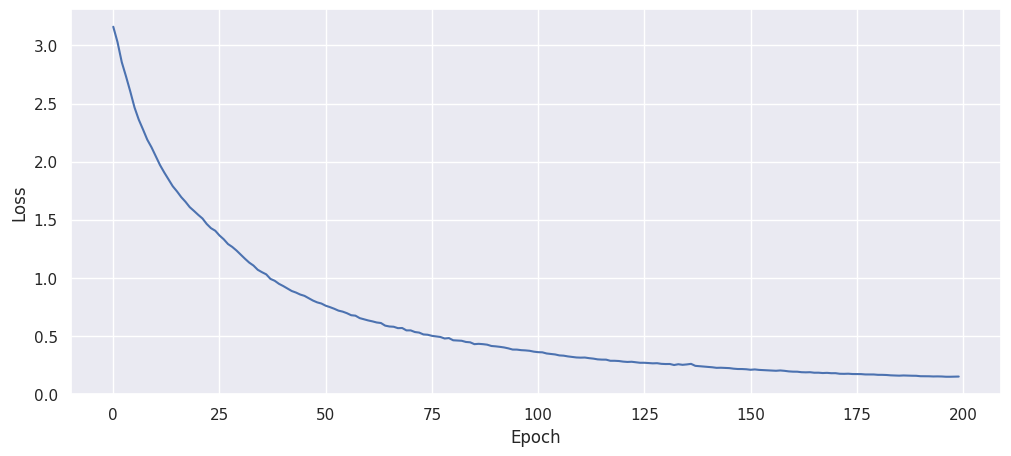

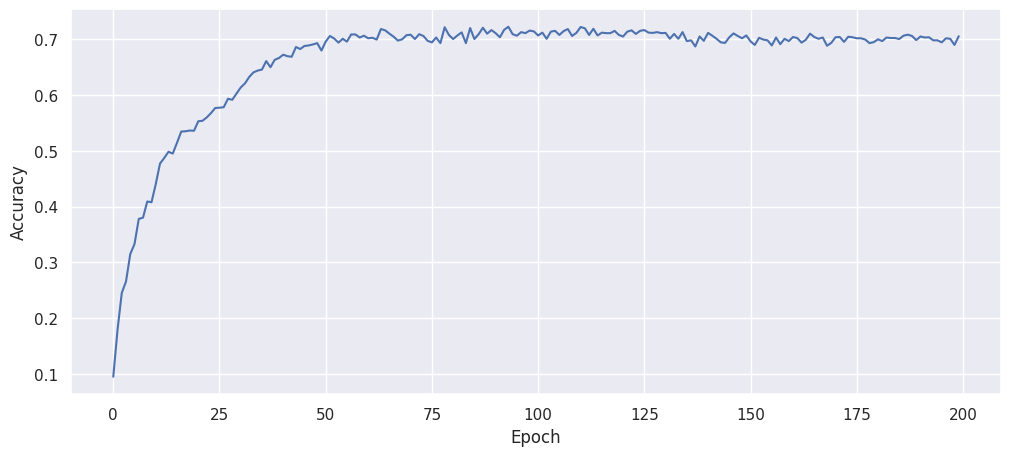

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(total_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(os.path.join(logPath, "loss_polloop.png"))

plt.figure(figsize=(12, 5))
plt.plot(total_accuracy)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig(os.path.join(logPath, "accuracy_polloop.png"))

In [25]:
import torch
import snntorch.spikeplot as splt
import numpy as np
from IPython.display import HTML
from matplotlib import ticker

sns.set_style("whitegrid")

batch_id = 3
sample_id = 10
x_test, y_test = shd_dl.test_epoch()
x = jnp.unpackbits(x_test[batch_id], axis=1)
pred_y, (s1, charge) = jax.vmap(model)(x)

fig, ax = plt.subplots(facecolor="w", figsize=(12, 7))
ax.set_title(f"Class {y_test[batch_id][sample_id]}")
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))
ax.grid(False)
anim = splt.spike_count(
    torch.as_tensor(np.asarray(pred_y[sample_id])),
    fig,
    ax,
    jnp.arange(20),
    animate=True,
    gridshader=True,
    time_step=0.014,
)
# plt.show()
plt.close()
HTML(anim.to_html5_video())

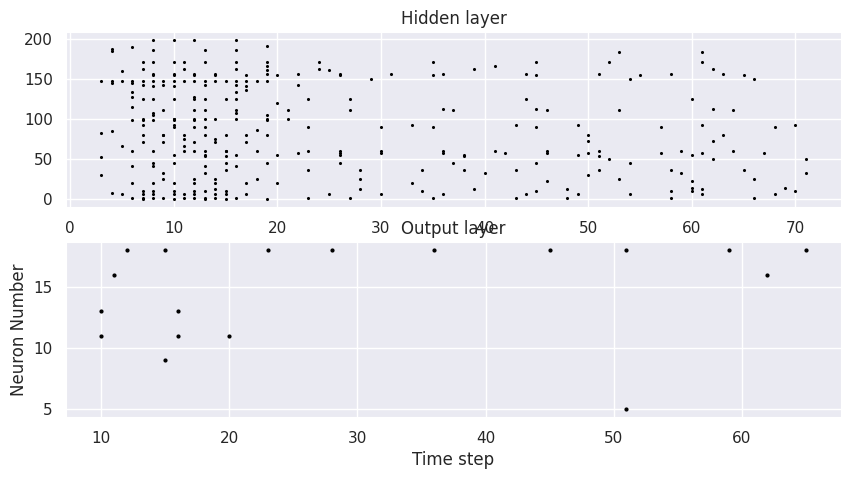

In [24]:
sns.set_style("darkgrid")

fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(211)
ax.set_title("Hidden layer")
splt.raster(torch.as_tensor(np.asarray(s1[sample_id])), ax, s=1.5, c="black")

ax = fig.add_subplot(212)
ax.set_title("Output layer")
splt.raster(torch.as_tensor(np.asarray(pred_y[sample_id])), ax, s=4, c="black")

plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

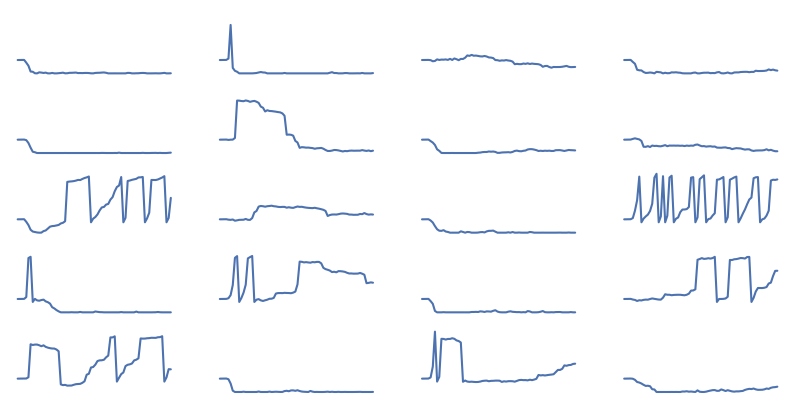

In [20]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
splt.traces(torch.as_tensor(np.asarray(charge[sample_id])), dim=(5, 4))
plt.show()